In [9]:
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

Load the dataset anperform a basic inspection.

In [11]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [17]:
df.shape

(541909, 8)

##### Dataset Information

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


##### Check Data Types

In [19]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

#### Check Missing Values

In [20]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [21]:
#### Check Duplicate Records

In [22]:
df.duplicated().sum()

np.int64(5268)

In [23]:
df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [24]:
df.shape

(536641, 8)

#### Handle Missing Values

In [26]:
df = df.dropna(subset=["CustomerID"])

df["Description"] = df["Description"].fillna("Unknown")

In [27]:
## Check Missing Values Again
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### Remove Invalid Transactions

In [30]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

#### Remove Cancelled Orders

In [32]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

##### Convert Invoice Date

In [33]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

#### Final Dataset Shape

In [34]:
df.shape

(392692, 8)

#### Create Total Amount Column

In [35]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [38]:
#### Average Purchase Value
average_purchase = df["TotalAmount"].mean()

print("Average Purchase Value:", round(average_purchase, 2))

Average Purchase Value: 22.63


In [39]:
purchase_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

print("Average Purchase Frequency:", round(purchase_frequency.mean(), 2))

Average Purchase Frequency: 4.27


In [41]:
#### Customer Lifetime Value

In [42]:
customer_ltv = df.groupby("CustomerID")["TotalAmount"].sum()

print("Average Customer Lifetime Value:", round(customer_ltv.mean(), 2))

Average Customer Lifetime Value: 2048.69


#### Mean, Median, Mode and Standard Deviation

In [47]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


#### Create Reference Date

In [49]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

#### Create RFM Table

In [50]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

#### Rename Columns

In [52]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [53]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [54]:
rfm.shape

(4338, 3)

#### Descriptive Statistics

rfm.describe()

rfm.isnull().sum()

#### Reset Index

In [60]:
rfm = rfm.reset_index()

#### Display Updated Dataset

In [61]:
rfm.head()

,index,CustomerID,Recency,Frequency,Monetary
0,0,12346.0,326,1,77183.60
1,1,12347.0,2,7,4310.00
2,2,12348.0,75,4,1797.24
3,3,12349.0,19,1,1757.55
4,4,12350.0,310,1,334.40


### Select Features for Clustering

In [63]:
rfm_data = rfm[["Recency", "Frequency", "Monetary"]]

rfm_data.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [64]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_data)

#### Check Scaled Data

In [65]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

#### Apply Elbow Method

In [68]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

#### Plot Elbow Curve

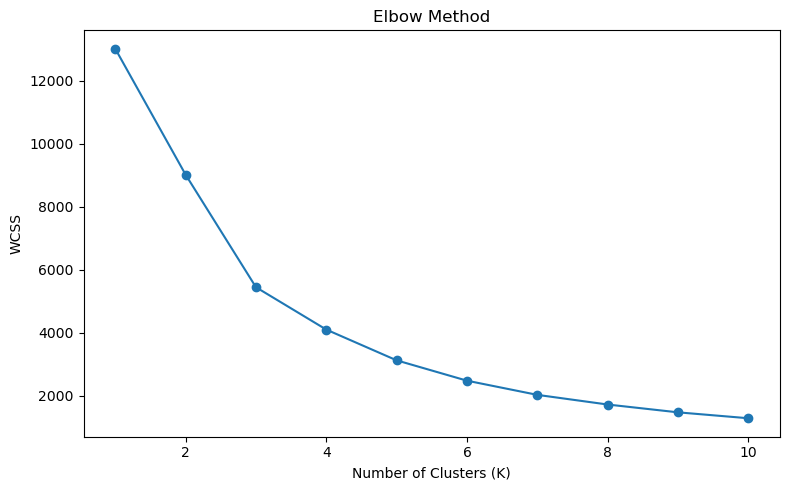

In [79]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

#### Apply K-Means Clustering

In [71]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

#### Display Clustered Data

In [72]:
rfm.head()

,index,CustomerID,Recency,Frequency,Monetary,Cluster
0,0,12346.0,326,1,77183.60,3
1,1,12347.0,2,7,4310.00,0
2,2,12348.0,75,4,1797.24,0
3,3,12349.0,19,1,1757.55,0
4,4,12350.0,310,1,334.40,1


#### Number of Customers in Each Cluster

In [73]:
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

#### Scatter Plot (Recency vs Monetary)

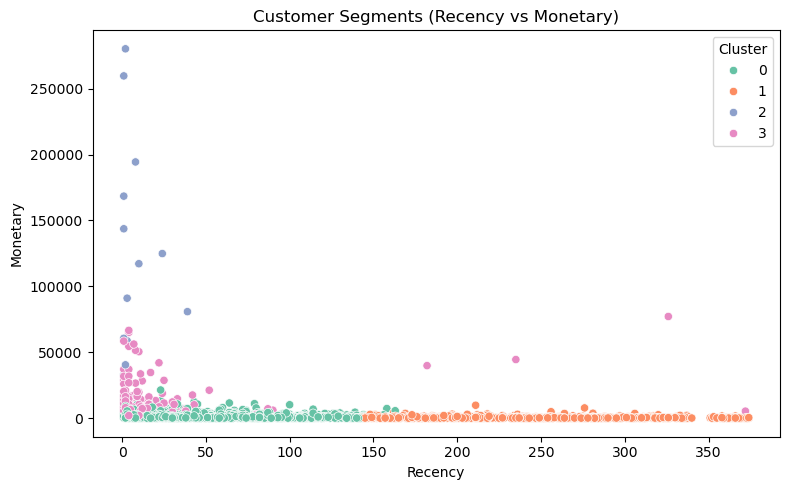

In [80]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments (Recency vs Monetary)")
plt.tight_layout()
plt.savefig("recency_vs_monetary.png", dpi=300, bbox_inches="tight")
plt.show()

#### Scatter Plot (Frequency vs Monetary)

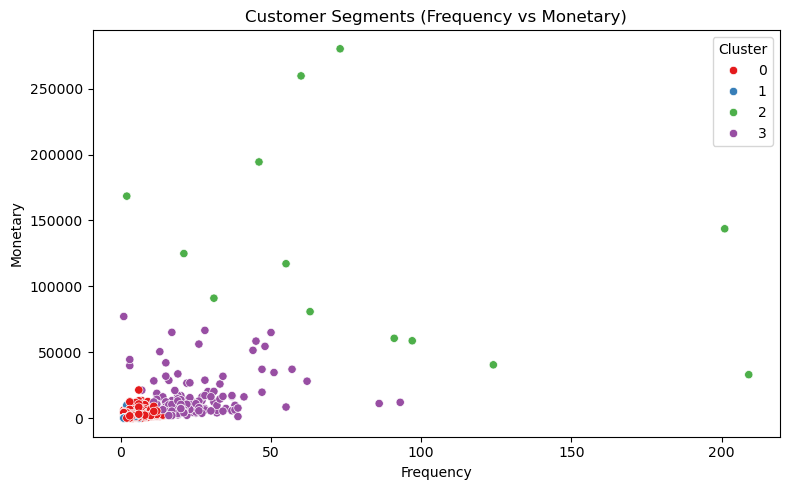

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments (Frequency vs Monetary)")
plt.tight_layout()
plt.savefig("frequency_vs_monetary.png", dpi=300, bbox_inches="tight")
plt.show()

##### Customers per Cluster

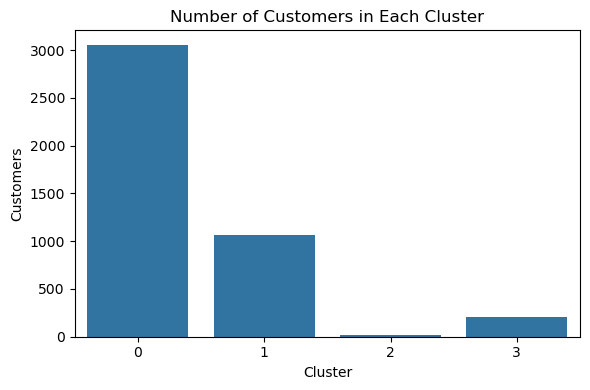

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(data=rfm, x="Cluster")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig("customers_per_cluster.png", dpi=300, bbox_inches="tight")
plt.show()